## Phase 1: Raw Data Consolidation

I'm loading all four workbooks (Electronics, Home Appliances, Fashion, Books). Each has 
multiple category sheets except Books, which is a single sheet. I'm tagging every row with 
`source_sheet` (the original sheet name) and `workbook` before concatenation, so this 
ground-truth signal survives consolidation. I'll use it later as a cross-check against `category_leaf`/`category_normalized`.

In [13]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data")

workbooks = {
    "Electronics": "Electronics.xlsx",
    "Home Appliances": "Home Appliances.xlsx",
    "Fashion": "Fashion.xlsx",
    "Books": "Books.xlsx",
}

all_sheets = []         # collection of individual sheets df before they're combined
sheet_shapes = {}       # dimensions of every sheet is going to be stored here

for workbook_name, filename in workbooks.items():
    sheets = pd.read_excel(DATA_DIR / filename, sheet_name=None, na_values=["—"])
    for sheet_name, df in sheets.items():
        df = df.copy()
        df["source_sheet"] = sheet_name
        df["workbook"] = workbook_name
        sheet_shapes[f"{workbook_name} / {sheet_name}"] = df.shape
        all_sheets.append(df)

raw_combined = pd.concat(all_sheets, ignore_index=True, sort=False)
raw_combined.shape

(8287, 26)

### Sanity checks: row counts and column consistency across sheets

Before doing anything else, I want to confirm total row volume against my ~5-8K target, and 
check whether any sheet is missing columns the others have. A missing column would just show 
up as extra NaNs post-concat and could go unnoticed, so I'm checking it explicitly here.

In [14]:
# Row count per sheet 

shape_df = pd.DataFrame(sheet_shapes, index=["rows","cols"]).T.sort_values("rows", ascending=False)
print(shape_df)
print(f"\nTotal rows combined: {raw_combined.shape[0]}")
print(f"\nTotal columns after concat: {raw_combined.shape[1]}")

                                     rows  cols
Books / Books                        1000    26
Electronics / Toys                    600    26
Home Appliances / Fridge              600    26
Fashion / Sunglass                    600    26
Home Appliances / Kitchen Appliance   560    26
Fashion / Shirt                       559    26
Fashion / Shoes                       520    26
Electronics / Keyboard                511    26
Electronics / Laptops                 498    26
Fashion / Cloth                       480    26
Fashion / Handbag                     480    26
Home Appliances / AC                  480    26
Electronics / Feature Phone           440    26
Home Appliances / TV                  399    26
Electronics / Softwares               360    26
Electronics / HDD                     200    26

Total rows combined: 8287

Total columns after concat: 26


8,287 rows total across 16 sheets — within my 5-8K target. HDD is the smallest at 200 rows.

I stopped scraping that category early because past ~200 the category page started surfacing 
off-topic products, so continuing would've added contamination rather than real coverage.

In [15]:
# Column consistency check — which sheets are missing which original columns
original_cols_per_sheet = {}
for workbook_name, filename in workbooks.items():
    sheets = pd.read_excel(DATA_DIR / filename, sheet_name=None, nrows=0)
    for sheet_name, df in sheets.items():
        original_cols_per_sheet[f"{workbook_name} / {sheet_name}"] = set(df.columns)

all_cols = set.union(*original_cols_per_sheet.values())
for sheet_id, cols in original_cols_per_sheet.items():
    missing = all_cols - cols
    if missing:
        print(f"{sheet_id} is missing: {missing}")

Since there is no output, every sheet has the same 26 columns after tagging. So I'm working with a clean union with no missing-column gaps to patch before moving on.

### Inspecting the Category column

Before I can build the normalization mapping, I need to see every unique raw `Category` 
value and how often each occurs. This is also where I'll spot the overlapping-path problem 
mentioned in my planning notes — e.g. "Software" potentially showing up under two different 
top-level categories.

In [16]:
category_counts = raw_combined["Category"].value_counts()
category_counts

Category
Media, Music & Books > Books > English Books                                           841
Fashion > Men > Clothing                                                               555
Fashion > Men > Shoes                                                                  495
Fashion > Women > Clothing                                                             478
Bags and Travel > Women Bags                                                           429
                                                                                      ... 
TV, Audio / Video, Gaming & Wearables > Console Gaming > Xbox                            1
TV, Audio / Video, Gaming & Wearables > Audio > Home Entertainment > Component S...      1
Watches Sunglasses Jewellery > Eyewear > Women                                           1
Bags and Travel                                                                          1
Media, Music & Books > Books                                                     

In [17]:
# Breadcrumb depth check — confirms the inconsistent-depth issue and shows its spread

print(f"Unique raw Category values: {category_counts.shape[0]}")

depth = raw_combined["Category"].str.split(">").str.len()
depth.value_counts().sort_index()


Unique raw Category values: 164


Category
1.0     431
2.0    2897
3.0    4502
4.0     450
Name: count, dtype: int64

164 unique raw Category values, with depth ranging from 1 to 4 segments. Depth 1 rows have 
no ">" separator at all, so I need to handle that as a valid case, not an error, when I build 
category_l1 and category_leaf. I'm exporting the full list to a CSV so I can review it outside 
the notebook and decide on normalization mappings for Section 6.

In [18]:
category_counts.to_csv("data/category_value_counts.csv")

### Finding real category overlaps using source_sheet as ground truth

Before manually deciding which raw Category paths mean the same thing, I want to check this 
systematically. Since source_sheet tells me what I actually scraped (a single product type per 
sheet), if one source_sheet's rows are spread across more than one raw Category path, that is a 
strong signal those paths represent the same real category and should be merged. This is more 
reliable than just eyeballing similar looking category strings.

In [19]:
sheet_category_map = (
    raw_combined.groupby(["source_sheet", "Category"])
    .size()
    .reset_index(name="rows")
    .sort_values(["source_sheet", "rows"], ascending=[True, False])
)
sheet_category_map

,source_sheet,Category,rows
6,AC,Home Appliances > Cooling & Heating > Air Cond...,272
5,AC,Home Appliances > Appliances Parts & Accessories,104
7,AC,Home Appliances > Cooling & Heating > Fan,11
26,AC,"TV, Audio / Video, Gaming & Wearables > Wearab...",11
9,AC,Laundry & Cleaning > Cleaning,10
...,...,...,...
231,Toys,Motors > Automotive > Exterior Accessories,1
234,Toys,Sports & Outdoors > Outdoor Recreation > Cycli...,1
237,Toys,"TV, Audio / Video, Gaming & Wearables > Audio ...",1
240,Toys,"TV, Audio / Video, Gaming & Wearables > Wearab...",1


In [20]:
sheet_category_map.to_csv("data/sheet_category_map.csv", index=False)

### Checking AC sheet minority categories for contamination

272 rows are core Air Conditioning, 104 are Appliances Parts & Accessories, both clearly 
legitimate and staying as is. The remaining rows are spread across 32 other category paths, 
too many to read one by one, so instead of manually opening each product, I am checking 
whether the product text actually mentions AC related terms. This gives me a fast first pass, 
rows that do not mention anything AC related are likely genuine contamination, rows that do 
are legitimate accessories that Daraz just filed under the wrong category.

In [21]:
ac_minority = raw_combined[
    (raw_combined["source_sheet"] == "AC") &
    (~raw_combined["Category"].isin([
        "Home Appliances > Cooling & Heating > Air Conditioning",
        "Home Appliances > Appliances Parts & Accessories"
    ]))
]

keywords = ["air condition", "\\bac\\b", "cooling", "compressor", "refrigerant", "conditioner", "air"]
pattern = "|".join(keywords)

ac_minority["mentions_ac"] = (
    ac_minority["Name"].str.cat(ac_minority["Description"], sep=" ", na_rep="")
    .str.lower()
    .str.contains(pattern, regex=True, na=False)
)

ac_minority.sort_values("mentions_ac")[["Category", "Name", "mentions_ac"]]

,Category,Name,mentions_ac
2875,Mobiles & Tablets > Mobile Accessories,Smartphone Remote Control IR Blasters Type C U...,False
3077,Motors > Automotive > Exterior Accessories,15cm Round/Square Shaped Portable Exhaust Pipe...,False
3050,Mobiles & Tablets > Mobile Accessories,Wall Phone Holder For Phone Mounted Storage Bo...,False
3009,"Tools, DIY & Outdoor > Fixtures & Plumbing",1-5M Washing Machine Draining Hose Thickened P...,False
3002,"TV, Audio / Video, Gaming & Wearables > Wearab...",Smart Phone Infrared Transmitter Universal Min...,False
...,...,...,...
2950,Motors > Automotive > Auto Tools & Equipment >...,AC Pro Cleaner Spray 450ml | Antibacterial AC ...,True
2942,Home Appliances > Vacuums & Floor Care,2500W Steam Cleaner High temperature Jet Washe...,True
2941,Home Appliances > Vacuums & Floor Care,High And Temperature Handheld Steam Cleaners A...,True
2959,"TV, Audio / Video, Gaming & Wearables > Wearab...",Smart RF 433 IR Remote Control Tuya WiFi Smart...,True


In [22]:
raw_combined = raw_combined.reset_index(drop=True)
raw_combined["row_id"] = raw_combined.index
raw_combined.to_csv("data/raw_combined.csv", index=False, encoding="utf-8-sig")

### Manual contamination findings, AC sheet

While reviewing AC's minority categories, I checked the products that came up under the 
keyword flag and found the following are not genuinely AC related, mostly generic multi-device 
accessories (covers, remotes, shrink wrap) that just happen to mention "air conditioner" as 
one of several supported devices, plus one automotive AC product that belongs to a different 
market entirely. I'm recording these row_id values now as known contamination, to be used both 
as manual overrides and as the calibration set for the TF-IDF threshold.

In [23]:
known_contamination_ids = {
    "AC": [3021, 3010, 2879, 3006, 2994, 3033, 3038, 3078, 3076, 3071, 3058, 2877,
           3049, 3041, 2931, 2925, 2924, 2916, 2908, 2903, 2978, 2975, 2961, 2952, 2972],
}

### TF-IDF contamination scoring, exploratory pass

I'm building the actual similarity check now, comparing each product's text (Name and 
Description combined) against the overall text profile of its own source_sheet. This gives 
every row a score between 0 and 1, showing how closely it matches what a typical product in 
that sheet looks like. Nothing gets removed at this stage, this is just calibration, I'm 
adding the score as a new column so I can look at where my known contamination rows from the 
AC sheet land, before deciding on a threshold.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Combine name and description into one text field per row
raw_combined["combined_text"] = (
    raw_combined["Name"].fillna("") + " " + raw_combined["Description"].fillna("")
)

# Fit TF-IDF across the whole dataset so all rows share the same vocabulary space
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(raw_combined["combined_text"])

# Build a centroid vector per source_sheet, the "typical" profile of that sheet's text
sheet_centroids = {}
for sheet in raw_combined["source_sheet"].unique():
    sheet_mask = (raw_combined["source_sheet"] == sheet).values
    sheet_centroids[sheet] = tfidf_matrix[sheet_mask].mean(axis=0)

# Score every row against its own sheet's centroid
scores = np.zeros(raw_combined.shape[0])
for sheet, centroid in sheet_centroids.items():
    sheet_mask = (raw_combined["source_sheet"] == sheet).values
    row_indices = np.where(sheet_mask)[0]
    sim = cosine_similarity(tfidf_matrix[row_indices], np.asarray(centroid))
    scores[row_indices] = sim.flatten()

raw_combined["category_similarity_score"] = scores
raw_combined["category_similarity_score"].describe()

count    8287.000000
mean        0.288530
std         0.156291
min         0.000000
25%         0.173350
50%         0.270291
75%         0.387207
max         0.851560
Name: category_similarity_score, dtype: float64

In [25]:
raw_combined[raw_combined["row_id"].isin(known_contamination_ids["AC"])][
    ["row_id", "Name", "category_similarity_score"]
].sort_values("category_similarity_score")

,row_id,Name,category_similarity_score
2931,2931,1.7/1.8M Foam Insulation Pipe 6-32mm Flame Ret...,0.073214
3049,3049,11PCS Tube Pipe Expander Hexagonal Handle Meta...,0.123717
2975,2975,Multifunctional Car Cup Holder Car Air Vent Cu...,0.137543
2978,2978,4Pcs 20cm Car Air Conditioner Vent Outlet Trim...,0.143541
2916,2916,Tube Expander 5 In 1 Copper Tube Expander Air ...,0.154395
2925,2925,2 Roll（4M） Air Conditioner Insulation Foam Tap...,0.157421
3071,3071,30-150pcs transparent shrink film bag anti-dus...,0.162498
2994,2994,For Toyota RAV4 WILDLANDER 2020-2025 2pcs Alum...,0.171663
3021,3021,New Ice silk air conditioner summer cooling qu...,0.184141
2908,2908,10Pcs 20cm Car Air Conditioner Outlet Decorati...,0.190521


In [26]:
raw_combined[raw_combined["source_sheet"] == "TV"]["category_similarity_score"].describe()

count    399.000000
mean       0.297237
std        0.179997
min        0.017994
25%        0.124954
50%        0.318952
75%        0.447901
max        0.677113
Name: category_similarity_score, dtype: float64

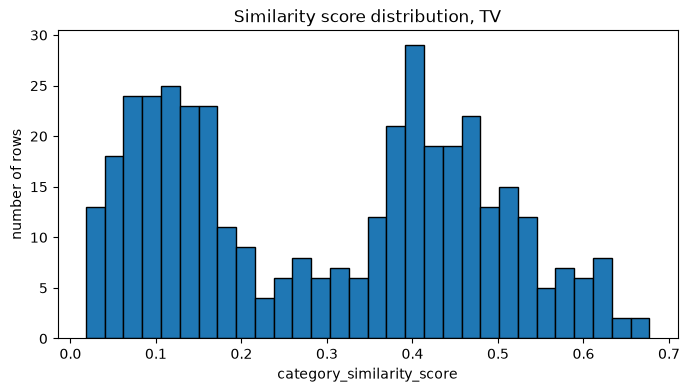

In [27]:
import matplotlib.pyplot as plt

sheet_to_check = "TV"
scores = raw_combined[raw_combined["source_sheet"] == sheet_to_check]["category_similarity_score"]

plt.figure(figsize=(8, 4))
plt.hist(scores, bins=30, edgecolor="black")
plt.title(f"Similarity score distribution, {sheet_to_check}")
plt.xlabel("category_similarity_score")
plt.ylabel("number of rows")
plt.show()

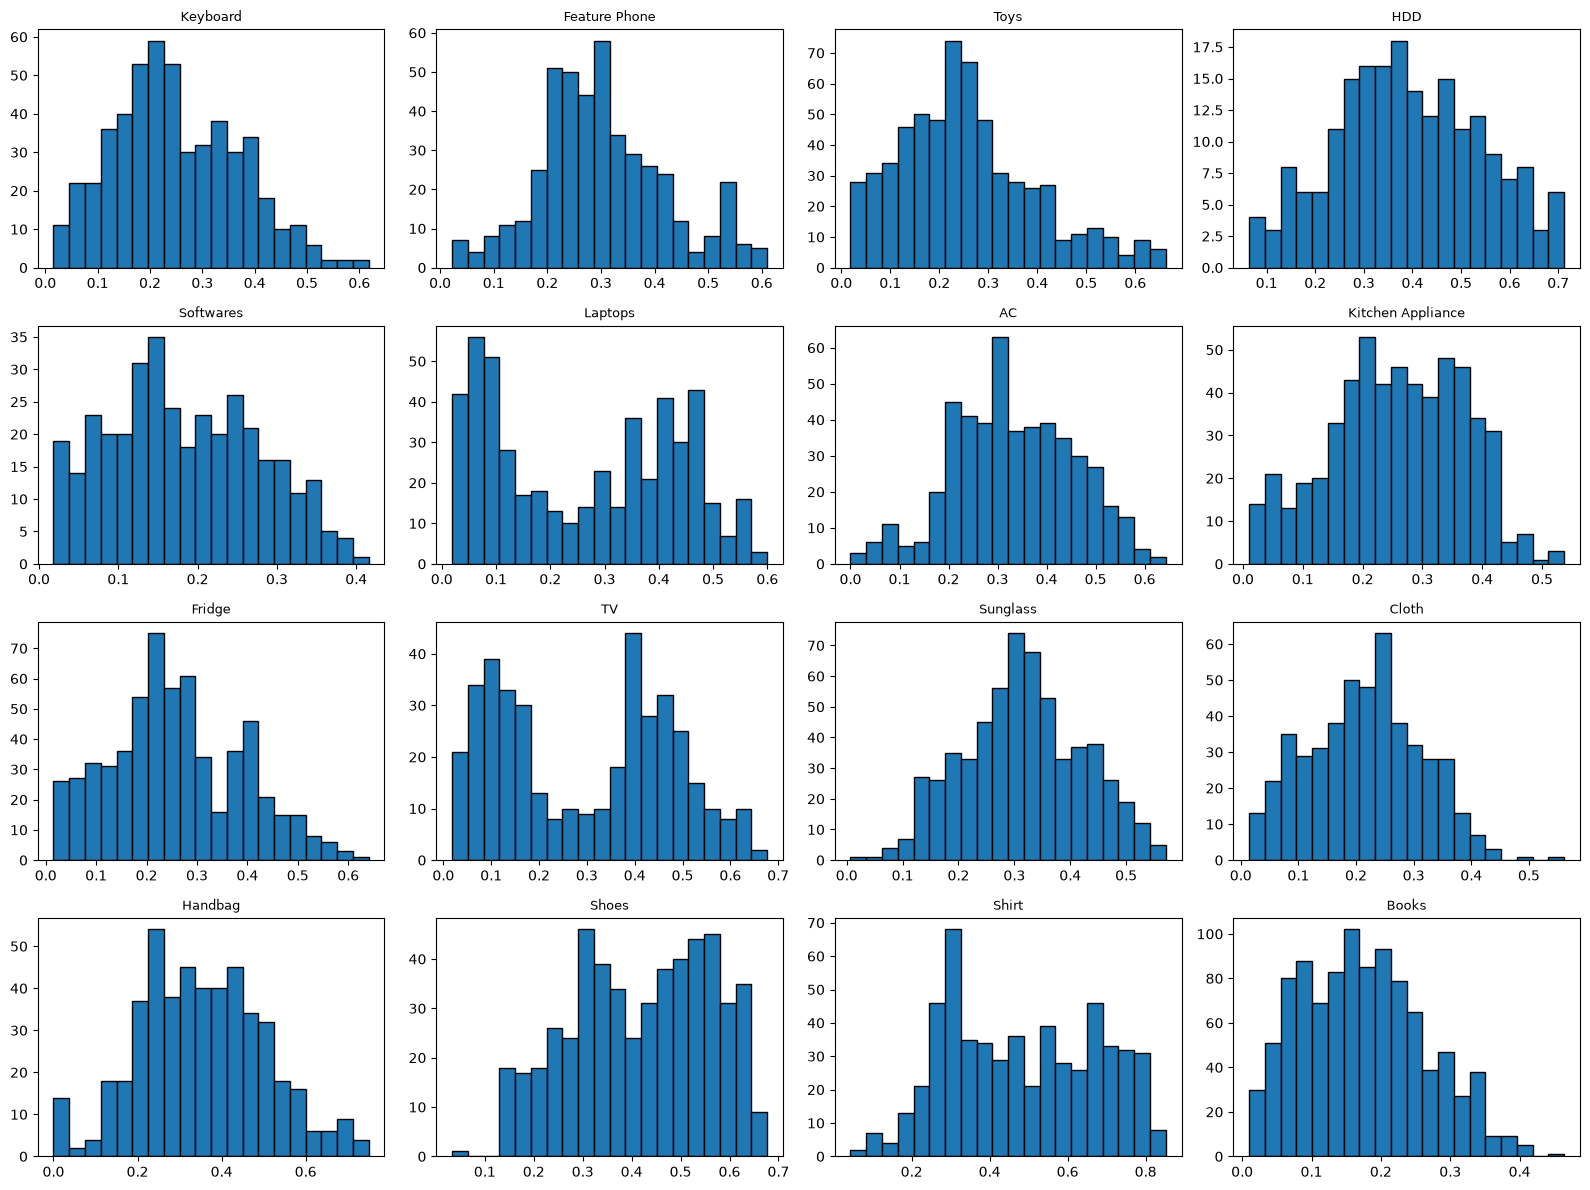

In [28]:
sheets = raw_combined["source_sheet"].unique()
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, sheet in zip(axes.flatten(), sheets):
    scores = raw_combined[raw_combined["source_sheet"] == sheet]["category_similarity_score"]
    ax.hist(scores, bins=20, edgecolor="black")
    ax.set_title(sheet, fontsize=9)
plt.tight_layout()
plt.show()

In [29]:
tv_rows = raw_combined[raw_combined["source_sheet"] == "TV"]

low_cluster = tv_rows[tv_rows["category_similarity_score"] < 0.2]
high_cluster = tv_rows[tv_rows["category_similarity_score"] > 0.35]

print(low_cluster[["Name", "category_similarity_score"]].sample(10, random_state=1))
print(high_cluster[["Name", "category_similarity_score"]].sample(10, random_state=1))

                                                   Name  \
4521  Laser Light 10 Miles 532nm Green Laser Pointer...   
4524                Airpods_Pro Tws Bluetooth Headphone   
4646  Silicone Soft Case for Airpod Pro & Pro 2 Wire...   
4545  VMEX LF-05 Headphone Heavy Bass 3.5Mm Port 1.2...   
4641  Mini MP3 Bluetooth Lossless Decoder Board Car ...   
4484  D7 Multimedia 2.0 Channel Speaker - USB Powere...   
4557  3D Foam Wall & ceiling Stickers 1 pcs 70*77 cm...   
4511  2-Layer Wall Mount WiFi Router Stand – Metal S...   
4580  HiFi Mini Speaker portable Bluetooth speaker -...   
4487  REALME BUDS 2 Wired Earphone - Headphone - Hea...   

      category_similarity_score  
4521                   0.032934  
4524                   0.134706  
4646                   0.106347  
4545                   0.065622  
4641                   0.128610  
4484                   0.071316  
4557                   0.021542  
4511                   0.111427  
4580                   0.153310  
4487      

### Setting a per sheet threshold instead of one global number

Since TV and Laptops showed a clear two cluster pattern in their histograms, and I confirmed 
by sampling that TV's lower cluster is genuine unrelated contamination (earphones, speakers, 
laser pointers, nothing to do with televisions), I'm setting a threshold on those sheets which has binomial distribution, based on 
where that valley sits in their histogram, instead of using one number for the whole dataset.

In [30]:
lp_rows = raw_combined[raw_combined["source_sheet"] == "Laptops"]

low_cluster = lp_rows[lp_rows["category_similarity_score"] < 0.18]
high_cluster = lp_rows[lp_rows["category_similarity_score"] > 0.25]

print(low_cluster[["Name", "category_similarity_score"]].sample(10, random_state=1))
print(high_cluster[["Name", "category_similarity_score"]].sample(10, random_state=1))

                                                   Name  \
2578  5 in 1 Multi-function Precision Screwdriver Se...   
2579  Embrace Digital Note-Taking With 12" Lcd Writi...   
2411  Custom Laptop Sticker Waterproof Removable Lap...   
2456  KISONLI U3100 Surround Bass Mini Speaker Stere...   
2544  4 Ports Usb 2.0 Hub Led Usb Hub With Switch - ...   
2424  D7 Multimedia Speaker Mini USB Port for Comput...   
2421  Logitech K120 Wired Keyboard for Windows, USB ...   
2435  Outdoor Small Mini Backpack And Laptop Bag - B...   
2464  KISONLI U3100 Surround Bass Mini Speaker Stere...   
2433  Modern Desktop Computer Desk With Keyboard Tra...   

      category_similarity_score  
2578                   0.026672  
2579                   0.061200  
2411                   0.112215  
2456                   0.060036  
2544                   0.082141  
2424                   0.103730  
2421                   0.055842  
2435                   0.107154  
2464                   0.047590  
2433      

So, after manually checking both Laptops and TV, since those two had the most visible dip in thier histogram, I've planned to move with setting a custom threshold of 0.18 and 0.2 respectively for them and 0.19 as a global threshold.

### Final contamination threshold decision

I tested three approaches: a single global threshold, per sheet thresholds based on where 
a histogram showed a clear split between junk and real products, and manual review for sheets 
where scores didn't separate cleanly. TV and Laptops both showed a clear two cluster pattern 
and I confirmed by sampling that the low cluster in both is genuine unrelated contamination, so 
I'm setting a specific threshold for those two. AC showed contamination scattered across the 
same range as real products with no clean separation, so I'm relying on the manual review I 
already did for that sheet instead of a score cutoff. For every other sheet, I'm using one 
global threshold based on eyeballing their histograms, this project isn't a production system 
so I'm accepting some imprecision here rather than manually reviewing all sixteen sheets.

In [31]:
default_threshold = 0.15  

sheet_thresholds = {
    "TV": 0.20,
    "Laptops": 0.18,
    "Softwares": 0.08,  
    "Books": 0.08,
}

raw_combined["contamination_threshold"] = raw_combined["source_sheet"].map(
    lambda s: sheet_thresholds.get(s, default_threshold)
)

raw_combined["flagged_contamination"] = (
    raw_combined["category_similarity_score"] < raw_combined["contamination_threshold"]
)

# AC gets its manual override list applied on top, regardless of score
raw_combined.loc[
    raw_combined["row_id"].isin(known_contamination_ids["AC"]), "flagged_contamination"
] = True

raw_combined["flagged_contamination"].value_counts()

flagged_contamination
False    6895
True     1392
Name: count, dtype: int64

In [32]:
raw_combined.groupby("source_sheet")["flagged_contamination"].mean().sort_values(ascending=False) * 100

source_sheet
TV                   41.102757
Laptops              40.763052
Cloth                26.875000
Toys                 24.166667
Fridge               21.000000
Keyboard             20.743640
Books                16.800000
Kitchen Appliance    16.785714
Softwares            16.666667
AC                   10.416667
Handbag               7.916667
Feature Phone         7.500000
Sunglass              6.666667
HDD                   5.500000
Shoes                 2.500000
Shirt                 2.146691
Name: flagged_contamination, dtype: float64

After lowering the threshold for Software and Books to match their naturally lower baseline 
similarity scores, both dropped to under 17% flagged, in line with the rest of the dataset. 
TV and Laptops remain around 40%, confirmed as a real finding through manual sampling.

## Phase 1 wrap up

This notebook took the four raw scraped workbooks (Electronics, Home Appliances, Fashion, 
Books) and combined them into one working dataset. Final result is 8287 rows across 26 
columns, pulled from 16 sheets, with source_sheet and workbook added during consolidation 
so I always know where each row originally came from. Column set was a clean union, no sheet 
was missing a field the others had.

I also worked out how I am going to handle two of the harder problems in this project before 
moving into actual cleaning.

Category normalization: Daraz's own Category field turned out to be unreliable, products were 
sometimes filed under categories that had nothing to do with what they actually are, an air 
conditioner cover ended up under Laundry and Cleaning for example. Because of this I decided 
category_normalized will come from source_sheet instead, since that is the one thing I know 
is accurate, I scraped it from that specific page myself. category_leaf will still come from 
the raw Category field, kept as a separate column rather than combined into one string, so 
both pieces of information are available without one looking like it belongs inside the other.

Contamination detection: I tested a TF-IDF similarity score comparing each product's text 
against a centroid built from its own sheet. This worked well for TV and Laptops, both showed 
a clear two cluster pattern and I confirmed by sampling that the low scoring cluster in both 
is genuine unrelated contamination, laser pointers and earphones showing up in TV for example. 
AC did not follow this pattern, its contamination overlapped in vocabulary with real products 
(car air conditioner accessories, multi device covers), so no score cutoff could separate them 
cleanly, I reviewed AC by hand instead and built a manual list of contaminated row IDs for it. 
Software and Books needed their own lower threshold too, not because of contamination, but 
because products in those sheets naturally score lower against their sheet's centroid even 
when they are completely legitimate. Final flagged rate came out to about 21 percent overall, 
with TV and Laptops sitting around 40 percent and everything else considerably lower.

Everything from here, category assignment, price and discount cleaning, deduplication by SKU, 
and the column drop list, moves into reusable pipeline functions instead of more notebook 
cells, since the whole point of this project is a pipeline that can run again on new batches, 
not a one time notebook cleanup.